# Play & Deck Diagnostics — why ladder Elo falls as training increases

Results only (tables / plots). Data sources, all engine-computed:
- `results/play_diag.json` — deck fixed to `metal_aggro`, pilot varied across the
  training trajectory (greedy → pre-coevo net → run7 rounds 1–6); win rate vs a
  diverse greedy panel + per-decision behaviour (`scripts/play_diag.py`).
- `results/deck_strength.json` — pilot fixed (greedy / run7 net), deck varied;
  field win rate of each candidate deck vs the diverse panel (`scripts/deck_strength.py`).
- Ladder Elo of the actual submissions (recorded from the Kaggle ladder).

In [1]:
import sys, json
from pathlib import Path
from collections import Counter

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.cards import load_cards
from src.deck import build_pool, card_kind
from src.qd.deck_qd import prize_points, setup_cost, behaviour_descriptor, prize_value

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PLAY = json.loads((ROOT / "results/play_diag.json").read_text())
DECKS = json.loads((ROOT / "results/deck_strength.json").read_text())
OPENING = json.loads((ROOT / "results/opening_diag.json").read_text())
NASH = json.loads((ROOT / "results/nashconv.json").read_text())
POOL = build_pool()
NAMES = load_cards("EN").set_index("card_id")["name"].to_dict()

def read_deck(name):
    return [int(x) for x in (ROOT / "decklists" / f"{name}.csv").read_text().split()]

## 1. The paradox: ladder Elo vs local win rate

Ladder Elo of the submissions, ordered by amount of learning baked into the agent
(greedy = none → co-evo run7 = most). Local field win rate (deck `metal_aggro`,
pilot = that agent, vs the diverse greedy panel) shown alongside.

,submission,training_stage,deck,ladder_elo
0,greedy + metal,"0: heuristic, no learning",metal_aggro,532.8
1,recurrent paper net + greedy deck,"1: BC/OSFP, pre-coevo",greedy/meta,494.1
2,ismcts (search),search (no net training),metal_aggro,440.3
3,recurrent run3_r6 + grass,2: 3 co-evo runs,grass,451.2
4,recurrent run7_r6 + run7_best,3: 7 co-evo runs,run7_best,NaN


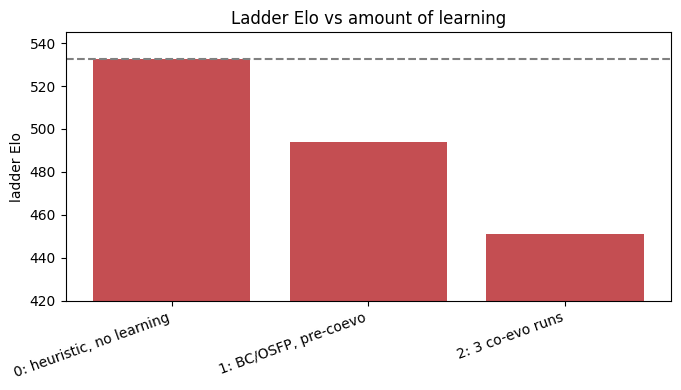

In [2]:
# Ladder Elo recorded from the Kaggle ladder (run7_r6 submission still settling).
ladder = pd.DataFrame([
    ("greedy + metal",            "0: heuristic, no learning", "metal_aggro", 532.8),
    ("recurrent paper net + greedy deck", "1: BC/OSFP, pre-coevo", "greedy/meta", 494.1),
    ("ismcts (search)",           "search (no net training)", "metal_aggro", 440.3),
    ("recurrent run3_r6 + grass", "2: 3 co-evo runs", "grass", 451.2),
    ("recurrent run7_r6 + run7_best", "3: 7 co-evo runs", "run7_best", np.nan),
], columns=["submission", "training_stage", "deck", "ladder_elo"])
display(ladder)

mono = ladder[ladder.training_stage.str[0].isin(list("0123"))].copy()
mono["stage"] = mono.training_stage.str[0].astype(int)
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(mono.training_stage, mono.ladder_elo, color="#c44e52")
ax.axhline(532.8, ls="--", c="grey"); ax.set_ylim(420, 545)
ax.set_ylabel("ladder Elo"); ax.set_title("Ladder Elo vs amount of learning")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

## 2. Deck composition vs normal-TCG deckbuilding

Card-type split, prize liability (Σ copies·(prize_value−1): Mega +2, ex +1), cheapest
attack cost, and energy colours for each candidate deck. The `typical Standard`
reference row is a normal modern Standard-format deck's range (Pokémon ~12–18,
Trainers ~22–34, Energy ~8–15).

,deck,pokemon,trainer,energy,ex,mega,prize_liability,min_atk_cost,descriptor,energy_colours
0,metal_aggro,12,17,31,8,4,16,1,"(4, 0)",{'M': 31}
1,run4_best,14,17,29,8,4,16,1,"(4, 0)",{'M': 29}
2,grass_aggro,12,17,31,4,4,12,2,"(3, 1)",{'G': 31}
3,run7_best,14,19,27,4,4,12,1,"(3, 0)",{'G': 27}
4,single_prize_psychic,12,17,31,0,0,0,1,"(0, 0)",{'P': 31}
5,typical Standard (ref),12-18,22-34,8-15,-,-,-,-,-,-


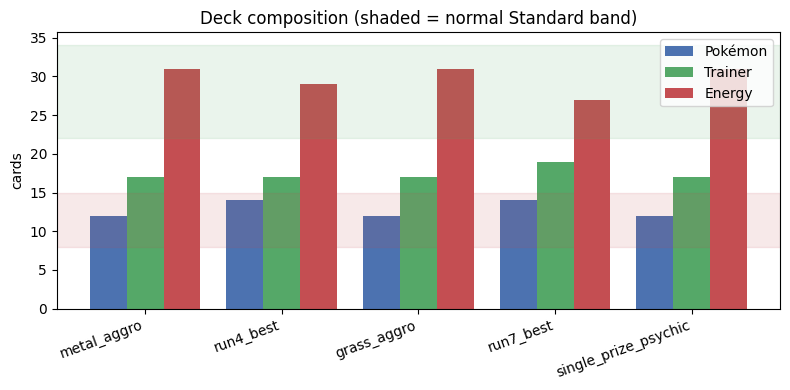

In [3]:
def deck_row(name):
    d = read_deck(name)
    k = Counter(card_kind(POOL, c) for c in d)
    n_ex = sum(POOL.cards[c].is_ex and not POOL.cards[c].is_mega for c in d if c in POOL.cards)
    n_mega = sum(POOL.cards[c].is_mega for c in d if c in POOL.cards)
    ecol = Counter(POOL.cards[c].card_type for c in d
                   if c in POOL.cards and card_kind(POOL, c) == "energy")
    return {
        "deck": name, "pokemon": k["pokemon"], "trainer": k["trainer"], "energy": k["energy"],
        "ex": n_ex, "mega": n_mega, "prize_liability": prize_points(d, POOL),
        "min_atk_cost": setup_cost(d, POOL), "descriptor": str(behaviour_descriptor(d, POOL)),
        "energy_colours": dict(ecol),
    }

rows = [deck_row(n) for n in
        ["metal_aggro", "run4_best", "grass_aggro", "run7_best", "single_prize_psychic"]]
rows.append({"deck": "typical Standard (ref)", "pokemon": "12-18", "trainer": "22-34",
             "energy": "8-15", "ex": "-", "mega": "-", "prize_liability": "-",
             "min_atk_cost": "-", "descriptor": "-", "energy_colours": "-"})
comp = pd.DataFrame(rows)
display(comp)

real = comp[comp.deck != "typical Standard (ref)"]
fig, ax = plt.subplots(figsize=(8,4))
x = np.arange(len(real)); w = 0.27
ax.bar(x-w, real.pokemon, w, label="Pokémon", color="#4c72b0")
ax.bar(x,   real.trainer, w, label="Trainer", color="#55a868")
ax.bar(x+w, real.energy,  w, label="Energy",  color="#c44e52")
ax.axhspan(22, 34, color="#55a868", alpha=.12)   # normal trainer band
ax.axhspan(8, 15, color="#c44e52", alpha=.12)     # normal energy band
ax.set_xticks(x); ax.set_xticklabels(real.deck, rotation=20, ha="right")
ax.set_ylabel("cards"); ax.set_title("Deck composition (shaded = normal Standard band)")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Deck power under a fixed pilot (deck vs play, separated)

Field win rate of each candidate deck vs the diverse greedy panel, piloted by
**greedy** (neutral reference) vs the **run7 net**. A deck that is weak under greedy
but strong under the net is co-adapted to that net.

,deck,greedy_pilot,net_pilot,net_lift
0,metal_aggro,0.658,0.746,0.088
1,run4_best,0.629,0.733,0.104
2,grass_aggro,0.458,0.699,0.241
3,run7_best,0.475,0.757,0.282
4,single_prize_psychic,0.025,0.054,0.029


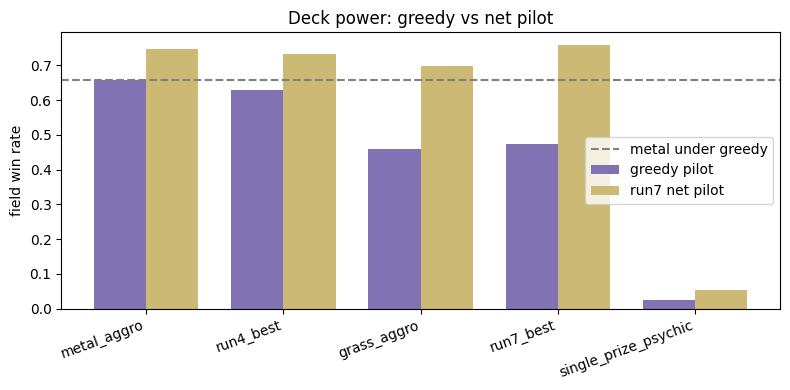

In [4]:
ov = DECKS["overall"]
cands = ["metal_aggro", "run4_best", "grass_aggro", "run7_best", "single_prize_psychic"]
ds = pd.DataFrame({
    "deck": cands,
    "greedy_pilot": [ov[f"greedy|{c}"]["winrate"] for c in cands],
    "net_pilot":    [ov[f"net|{c}"]["winrate"] for c in cands],
})
ds["net_lift"] = (ds.net_pilot - ds.greedy_pilot).round(3)
display(ds)

fig, ax = plt.subplots(figsize=(8,4))
x = np.arange(len(ds)); w = 0.38
ax.bar(x-w/2, ds.greedy_pilot, w, label="greedy pilot", color="#8172b3")
ax.bar(x+w/2, ds.net_pilot,    w, label="run7 net pilot", color="#ccb974")
ax.axhline(ov["greedy|metal_aggro"]["winrate"], ls="--", c="grey",
           label="metal under greedy")
ax.set_xticks(x); ax.set_xticklabels(ds.deck, rotation=20, ha="right")
ax.set_ylabel("field win rate"); ax.set_title("Deck power: greedy vs net pilot")
ax.legend(); plt.tight_layout(); plt.show()

## 4. How play changes across the training trajectory (deck fixed = metal)

Per-decision behaviour for greedy (reference) and each checkpoint. All pilot the
**same** `metal_aggro` deck, so differences are pure play. `first_attack_turn` =
setup speed; `pass_rate` = fraction of main decisions that ended the turn with other
actions still legal; `attach_per_game` = energy attachments; `ability` = share of
main decisions using an Ability; `prizes_taken/lost` = prize race.

,subject,avg_turns,first_attack_turn,pct_no_attack,pass_rate,attach/game,ability_share,bench_by_t3,max_bench,prizes_taken,prizes_lost
0,greedy(ref),12.3,3.57,0.004,0.009,6.81,0.270,3.22,4.55,6.0,5.63
1,init(pre-coevo),16.9,4.33,0.037,0.072,7.42,0.018,3.21,4.59,6.0,5.77
2,run7_r1,12.6,3.67,0.019,0.007,5.03,0.134,3.17,3.90,6.0,5.58
3,run7_r2,11.9,3.82,0.011,0.007,4.37,0.154,2.93,3.75,6.0,5.57
4,run7_r3,12.4,4.44,0.019,0.007,4.74,0.182,3.23,3.76,6.0,5.70
5,run7_r4,12.2,4.11,0.015,0.004,4.79,0.173,3.26,3.99,6.0,5.70
6,run7_r5,11.8,3.72,0.011,0.004,4.46,0.151,3.00,3.77,6.0,5.63
7,run7_r6(submitted),12.1,3.44,0.011,0.002,4.84,0.114,2.91,3.71,6.0,5.60


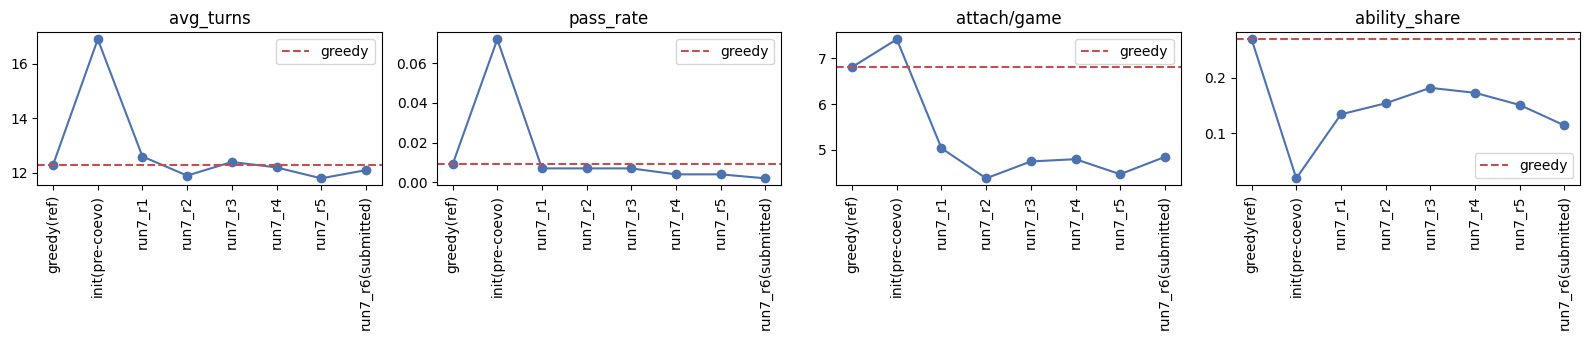

In [5]:
B = PLAY["behaviour"]
order = ["greedy(ref)", "init(pre-coevo)", "run7_r1", "run7_r2", "run7_r3",
         "run7_r4", "run7_r5", "run7_r6(submitted)"]
order = [s for s in order if s in B]
beh = pd.DataFrame([{
    "subject": s, "avg_turns": B[s]["avg_turns"],
    "first_attack_turn": B[s]["first_attack_turn"],
    "pct_no_attack": B[s]["pct_no_attack_game"], "pass_rate": B[s]["pass_rate"],
    "attach/game": B[s]["attach_per_game"], "ability_share": B[s]["act_mix"].get("ability", 0),
    "bench_by_t3": B[s]["bench_by_turn3"], "max_bench": B[s]["max_bench"],
    "prizes_taken": B[s]["prizes_taken"], "prizes_lost": B[s]["prizes_lost"],
} for s in order])
display(beh)

g = B["greedy(ref)"]
metrics = [("avg_turns", "avg_turns", g["avg_turns"]),
           ("pass_rate", "pass_rate", g["pass_rate"]),
           ("attach/game", "attach_per_game", g["attach_per_game"]),
           ("ability_share", None, g["act_mix"].get("ability", 0))]
fig, axes = plt.subplots(1, 4, figsize=(16,3.5))
for ax,(title,key,gref) in zip(axes, metrics):
    col = {"avg_turns":"avg_turns","pass_rate":"pass_rate","attach/game":"attach/game",
           "ability_share":"ability_share"}[title]
    ax.plot(beh.subject, beh[col], "o-", color="#4c72b0")
    ax.axhline(gref, ls="--", c="#c44e52", label="greedy")
    ax.set_title(title); ax.tick_params(axis="x", rotation=90); ax.legend()
plt.tight_layout(); plt.show()

## 5. Action mix on the fixed deck (greedy vs trained nets)

Fraction of main-phase decisions by action type.

,play,attach,attack,ability,retreat,end
greedy(ref),0.314,0.215,0.150,0.270,0.000,0.051
init(pre-coevo),0.404,0.265,0.213,0.018,0.003,0.097
run7_r1,0.346,0.231,0.218,0.134,0.000,0.072
run7_r2,0.340,0.214,0.225,0.154,0.000,0.066
run7_r3,0.315,0.217,0.203,0.182,0.000,0.083
run7_r4,0.335,0.216,0.206,0.173,0.000,0.069
run7_r5,0.340,0.219,0.228,0.151,0.000,0.063
run7_r6(submitted),0.340,0.243,0.235,0.114,0.000,0.068


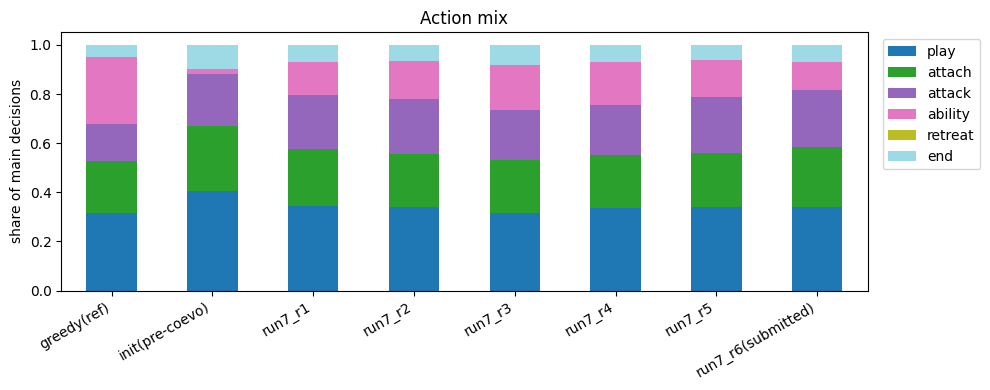

In [6]:
am = pd.DataFrame({s: B[s]["act_mix"] for s in order}).T.fillna(0)
cols = [c for c in ["play","attach","attack","ability","evolve","retreat","end"] if c in am.columns]
am = am[cols]
display(am.round(3))
am.plot(kind="bar", stacked=True, figsize=(10,4), colormap="tab20")
plt.ylabel("share of main decisions"); plt.title("Action mix")
plt.xticks(rotation=30, ha="right"); plt.legend(bbox_to_anchor=(1.01,1)); plt.tight_layout(); plt.show()

## 6. Play strength on the fixed deck vs a diverse opponent panel

Win rate piloting `metal_aggro`: vs greedy on the *same* deck (mirror, in-distribution),
vs the mean of the *other* type decks (off-deck panel), and vs the whole field — across
the training trajectory, with the greedy reference.

,subject,vs_mirror,vs_offdeck,vs_all_field
0,greedy(ref),0.533,0.748,0.752
1,init(pre-coevo),0.300,0.700,0.659
2,run7_r1,0.600,0.729,0.744
3,run7_r2,0.767,0.714,0.748
4,run7_r3,0.600,0.771,0.767
5,run7_r4,0.500,0.710,0.719
6,run7_r5,0.767,0.762,0.785
7,run7_r6(submitted),0.600,0.762,0.759


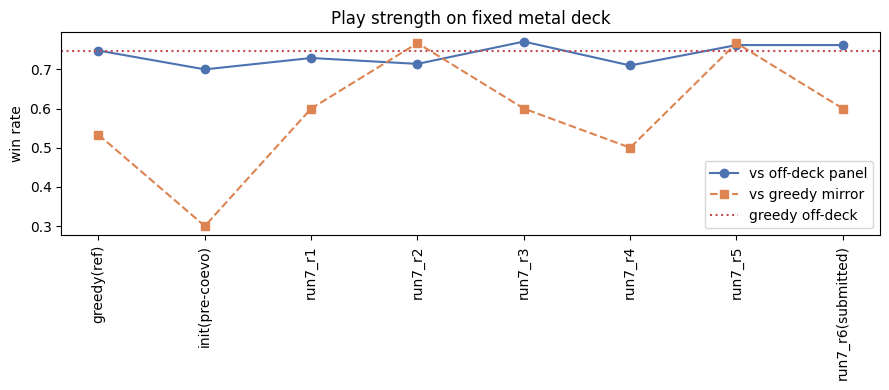

In [7]:
S = PLAY["summary"]
gap = pd.DataFrame([{
    "subject": s, "vs_mirror": S[s]["vs_greedy_mirror"],
    "vs_offdeck": S[s]["vs_offdeck_mean"], "vs_all_field": S[s]["vs_all"]["winrate"],
} for s in order])
display(gap)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(gap.subject, gap.vs_offdeck, "o-", label="vs off-deck panel", color="#4c72b0")
ax.plot(gap.subject, gap.vs_mirror, "s--", label="vs greedy mirror", color="#dd8452")
gref = S["greedy(ref)"]["vs_offdeck_mean"]
ax.axhline(gref, ls=":", c="#c44e52", label="greedy off-deck")
ax.set_ylabel("win rate"); ax.set_title("Play strength on fixed metal deck")
ax.tick_params(axis="x", rotation=90); ax.legend(); plt.tight_layout(); plt.show()

### Per-opponent win-rate heatmap (fixed metal deck)

,greedy/darkness,greedy/fighting,greedy/fire,greedy/grass,greedy/lightning,greedy/metal,greedy/psychic,greedy/water,random/metal
greedy(ref),0.767,0.600,0.400,0.800,0.700,0.533,1.000,0.967,1.000
init(pre-coevo),0.800,0.733,0.333,0.833,0.533,0.300,0.933,0.733,0.733
run7_r1,0.867,0.500,0.333,0.900,0.700,0.600,0.900,0.900,1.000
run7_r2,0.733,0.300,0.467,1.000,0.600,0.767,1.000,0.900,0.967
run7_r3,0.867,0.533,0.433,0.967,0.667,0.600,1.000,0.933,0.900
run7_r4,0.800,0.433,0.300,0.867,0.633,0.500,0.967,0.967,1.000
run7_r5,0.833,0.433,0.433,0.867,0.833,0.767,0.967,0.967,0.967
run7_r6(submitted),0.833,0.467,0.600,0.833,0.633,0.600,1.000,0.967,0.900


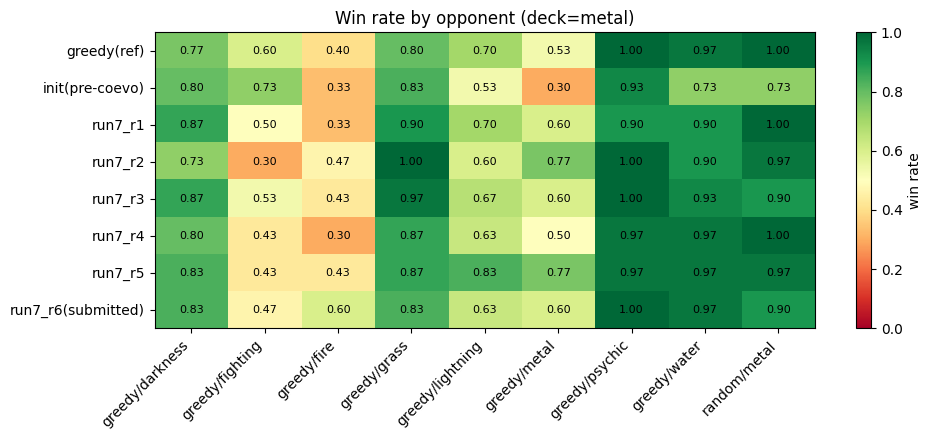

In [8]:
PO = PLAY["per_opponent"]
opps = sorted({o for s in order for o in PO[s]})
mat = pd.DataFrame([[PO[s].get(o, {}).get("winrate", np.nan) for o in opps] for s in order],
                   index=order, columns=opps)
display(mat)
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(mat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(opps))); ax.set_xticklabels(opps, rotation=45, ha="right")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
for i in range(len(order)):
    for j in range(len(opps)):
        v = mat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="win rate"); plt.title("Win rate by opponent (deck=metal)")
plt.tight_layout(); plt.show()

## 7. Opening-play adherence vs Pokémon-TCG conventions

Normative early-game principles (non-self-referential, so independent of the local
win-rate signal that doesn't track the ladder). Deck fixed to `metal_aggro`.
- **go_first_rate** — convention: go first by default (extra attach/draw/setup); go
  second mainly for fast 1-energy decks. `greedy + metal` (the top ladder submission)
  is the reference.
- **bench_after_t1/t2** — develop the board with Basics early.
- **attach_per_early_turn** — attach your one energy each early turn (tempo).
- **attach_last_rate** — energy attach is irreversible → ideally the last develop step.
- **wasted_turn_rate** — fraction of first-3 own turns that did nothing but End.

Sources: PokéCardHQ first-turn rules; SixPrizes / PokéBeach go-first-vs-second;
TCG Protectors intermediate strategy (attach energy last, prize-trade).

,subject,go_first_rate,bench_after_t1,bench_after_t2,attach_per_early_turn,attach_last_rate,wasted_turn_rate
0,greedy(ref),1.0,1.88,3.00,0.997,0.003,0.000
1,init(pre-coevo),1.0,1.87,3.01,0.883,0.672,0.023
2,run7_r1,0.0,2.80,3.20,0.942,0.012,0.000
3,run7_r2,0.0,2.57,2.87,0.920,0.047,0.000
4,run7_r3,0.0,2.60,3.00,0.897,0.047,0.000
5,run7_r4,0.0,2.62,3.16,0.928,0.062,0.000
6,run7_r5,0.0,2.67,3.01,0.891,0.040,0.000
7,run7_r6(submitted),0.0,2.63,2.98,0.907,0.081,0.000


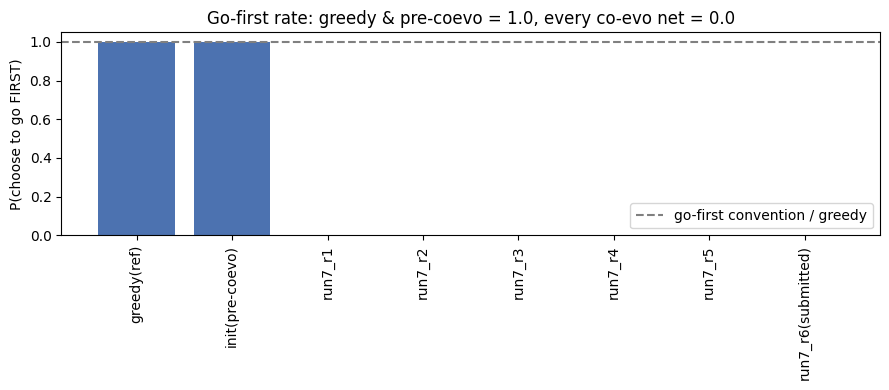

In [9]:
O = OPENING
oorder = [s for s in order if s in O]
opn = pd.DataFrame([{
    "subject": s, "go_first_rate": O[s]["go_first_rate"],
    "bench_after_t1": O[s]["bench_after_t1"], "bench_after_t2": O[s]["bench_after_t2"],
    "attach_per_early_turn": O[s]["attach_per_early_turn"],
    "attach_last_rate": O[s]["attach_last_rate"],
    "wasted_turn_rate": O[s]["wasted_turn_rate"],
} for s in oorder])
display(opn)

fig, ax = plt.subplots(figsize=(9,4))
colors = ["#c44e52" if v == 0 else "#4c72b0" for v in opn.go_first_rate]
ax.bar(opn.subject, opn.go_first_rate, color=colors)
ax.axhline(1.0, ls="--", c="grey", label="go-first convention / greedy")
ax.set_ylabel("P(choose to go FIRST)")
ax.set_title("Go-first rate: greedy & pre-coevo = 1.0, every co-evo net = 0.0")
ax.tick_params(axis="x", rotation=90); ax.legend(); plt.tight_layout(); plt.show()

## 8. Restricted NashConv (exploitability) over a strategy population

A "strategy" = a (pilot, deck) pair. From the win matrix W (every pair, slot-swapped),
for the symmetric profile "everyone plays i":
`exploitability(i) = 0.5 − min_j W[i][j]` (its worst matchup), `NashConv(i) = 2·that`.
**Lower NashConv = harder to exploit = more robust** (what the ladder rewards). The pool
includes exploiter probes (a forced-go-first greedy, type-variety decks); restricted
NashConv is a *lower bound* — only as strong as the pool. Source: `scripts/nashconv_eval.py`.
Across the `*|metal` strategies the deck is shared, so NashConv differences are pure play;
comparing `net_run7|metal` vs `net_run7|run7_best` isolates the deck.

,strategy,nashconv,exploitability,worst_vs,worst_winrate,mean_winrate
0,greedy|fire,-0.067,-0.033,greedy|metal,0.533,0.750
1,net_run7|metal,0.133,0.067,greedy|fire,0.433,0.710
2,net_run3|metal,0.200,0.100,net_run7|metal,0.400,0.660
3,greedy|metal,0.267,0.133,greedyFF|metal,0.367,0.640
4,greedyFF|metal,0.400,0.200,net_run3|metal,0.300,0.690
5,net_init|metal,0.733,0.367,net_run3|metal,0.133,0.480
6,net_run7|run7_best,0.800,0.400,greedy|fire,0.100,0.557
7,net_run3|grass,0.800,0.400,greedyFF|metal,0.100,0.500
8,random|metal,1.000,0.500,greedy|metal,0.000,0.080
9,greedy|run7_best,1.000,0.500,greedy|fire,0.000,0.327


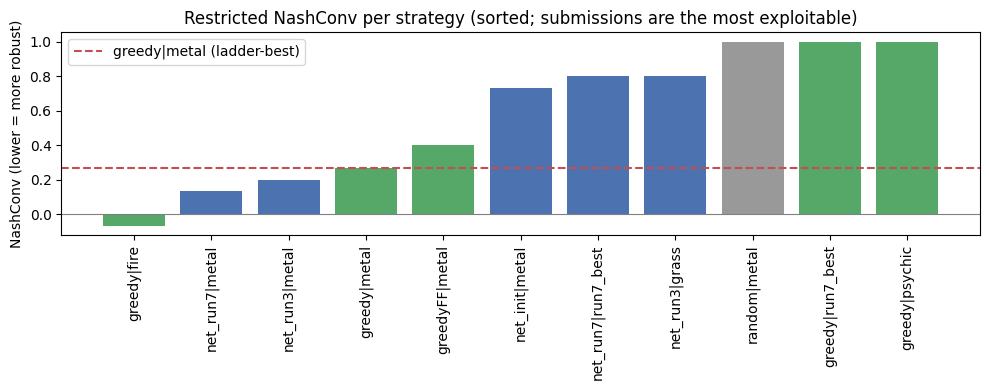

In [10]:
ncv = pd.DataFrame(NASH["per_strategy_nashconv"])
display(ncv)

def scolor(s):
    if s.startswith("net"): return "#4c72b0"
    if s.startswith("random"): return "#999999"
    return "#55a868"
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(ncv.strategy, ncv.nashconv, color=[scolor(s) for s in ncv.strategy])
ax.axhline(0, c="grey", lw=.8)
gm = ncv.loc[ncv.strategy == "greedy|metal", "nashconv"]
if len(gm):
    ax.axhline(gm.iloc[0], ls="--", c="#c44e52", label="greedy|metal (ladder-best)")
ax.set_ylabel("NashConv (lower = more robust)")
ax.set_title("Restricted NashConv per strategy (sorted; submissions are the most exploitable)")
ax.tick_params(axis="x", rotation=90); ax.legend(); plt.tight_layout(); plt.show()

### Win matrix W[i][j] = P(row beats col), and the Nash mixture

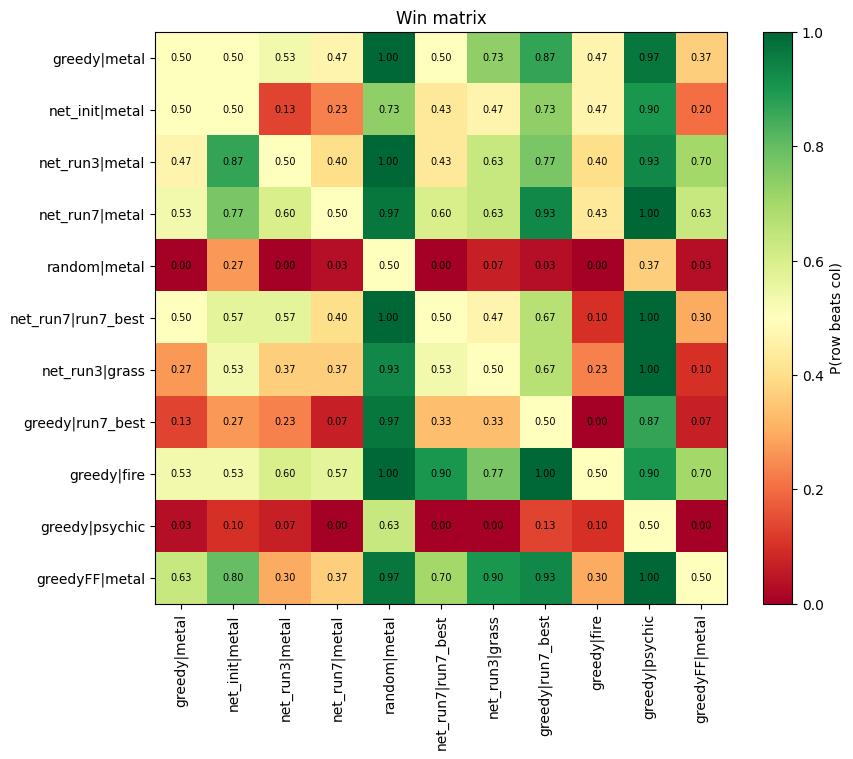

Nash support (clone-invariant robust core): {'greedy|fire': 1.0}
NashConv of the Nash mixture (~0 check): 0.0


In [11]:
labels = NASH["labels"]
W = np.array(NASH["win_matrix"])
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(W, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{W[i,j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="P(row beats col)")
ax.set_title("Win matrix"); plt.tight_layout(); plt.show()

print("Nash support (clone-invariant robust core):", NASH["nash_mixture"])
print("NashConv of the Nash mixture (~0 check):", NASH["nashconv_of_nash"])